# Phase 3B - Themes by Country Analysis

I will use NLP techniques to classify the URL-slugs for themes in a hope to get more insights into the narrative framing each country uses in their news coverage.

Example:
- https://thesil.ca/mcmaster-athletes-show-out-in-2026-milano-cortina-winter-olympics/
- https://wdet.org/2026/02/25/the-metro-team-usa-women-shine-as-americans-bring-home-33-medals-at-the-2026-winter-olympics/



In [1]:
import sys
!{sys.executable} -m pip install -q -U google-cloud-bigquery google-cloud-bigquery-storage pyarrow db-dtypes pandas-gbq

In [3]:
import tldextract
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [5]:
# load query data from repo

data_path = Path("../data/gdelt_gkg_feb2026_relevance_ladder_lvl3_mapped.parquet")
df = pd.read_parquet(data_path, engine="pyarrow")
# df["day"] = pd.to_datetime(df["day"])

df.shape

(30565, 24)

In [7]:
# Focus on strict tier
df_strict = df[df["rel_strict"]].copy()

In [9]:
def clean_slug(url):
    if not isinstance(url, str):
        return ""
    
    path = urlparse(url).path.lower()
    
    # remove digits
    path = re.sub(r"\d+", " ", path)
    
    # replace hyphens & slashes with spaces
    path = path.replace("-", " ").replace("/", " ")
    
    # remove non-letters
    path = re.sub(r"[^a-z\s]", " ", path)
    
    # collapse spaces
    path = re.sub(r"\s+", " ", path).strip()
    
    return path

df_strict["slug_text"] = df_strict["url"].apply(clean_slug)
df_strict["slug_text"].head()

0    la fiamma paralimpica di milano cortina accend...
1    news article the winter olympics story beijing...
2    mcmaster athletes show out in milano cortina w...
3    television is alysa liu done figure skating af...
4    the metro team usa women shine as americans br...
Name: slug_text, dtype: object

In [13]:
# Remove garbled slugs
def is_garbled_slug(s: str) -> bool:
    if not isinstance(s, str):
        return True
    
    s = s.strip().lower()
    if len(s) < 25:
        return True
    
    # too few alphabetic chars relative to length
    alpha = sum(c.isalpha() for c in s)
    if alpha / max(len(s), 1) < 0.7:
        return True
    
    # too many very short tokens (random gibberish)
    toks = s.split()
    if len(toks) >= 6:
        short = sum(len(t) <= 2 for t in toks)
        if short / len(toks) > 0.5:
            return True
    
    # looks like "article xxxx yyy zzz" (template garbage)
    if re.match(r"^article\s+[a-z]{2,4}\s+[a-z]{2,4}\s+[a-z]{2,4}", s):
        return True
    
    return False

In [15]:
# Filter out garbled slugs
df_strict["garbled"] = df_strict["slug_text"].apply(is_garbled_slug)

In [17]:
df_strict["garbled"].mean(), df_strict.shape

(0.03307155913614515, (29542, 26))

In [19]:
# only keep slugs with length >20
df_zs = df_strict[df_strict["slug_text"].str.len() > 20].copy()
df_zs.shape

(29514, 26)

In [21]:
df_zs = df_strict[~df_strict["garbled"]].copy()
df_zs.shape

(28565, 26)

## Text Classification with NLP model

My goal is to classify the url slugs into themes to better understand what each country reports on.

Model:
- mDeBERTa-v3-base-mnli-xnli

This multilingual model can perform natural language inference (NLI) on 100 languages and is therefore also suitable for multilingual zero-shot classification.

Classification Categories (Themes):
- "medal victories and competition results",
- "athlete profile or human interest story",
- "broadcast ratings and business of the Olympics",
- "controversy, scandal, or rule violation",
- "politics or geopolitical story",
- "climate, weather, or snow conditions",
- "logistics, infrastructure, or host city preparations"

In [23]:
import sys
!{sys.executable} -m pip install -q huggingface_hub requests

In [25]:
#from bertopic import BERTopic
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from huggingface_hub import InferenceClient
import os, time, json, hashlib
from pathlib import Path
import pandas as pd

In [26]:
os.environ["HF_TOKEN"] = "INSERT_TOKEN"

In [27]:
# Make sure Huggingface token is set
assert "HF_TOKEN" in os.environ and os.environ["HF_TOKEN"], "Set os.environ['HF_TOKEN'] first"

In [28]:
# Sample 100 articles per country
MIN_N = 100
MAX_PER_COUNTRY = 200

counts = df_zs["publisher_country_final"].value_counts()
countries = counts[counts >= MIN_N].index.tolist()

sample_df = (
    df_zs[df_zs["publisher_country_final"].isin(countries)]
    .groupby("publisher_country_final", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), MAX_PER_COUNTRY), random_state=42))
    .reset_index(drop=True)
)

sample_df.shape, sample_df[["publisher_country_final","slug_text"]].head()

/var/folders/gc/cn0r60wn7j5bsfkl23_ym9_80000gn/T/ipykernel_3868/3284127036.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), MAX_PER_COUNTRY), random_state=42))


((2073, 26),
   publisher_country_final                                          slug_text
 0               Australia  story winter olympics why valentino guseli jos...
 1               Australia  news china xu mengtao defends women aerials go...
 2               Australia  news laura peel milano cortina winter olympics...
 3               Australia  news latest news just in winter olympics retur...
 4               Australia  story cooper woods wins gold at milan cortina ...)

In [33]:
# use GPU if available (locally on Mac M4)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [35]:
# Load model and tokenizer
model_name = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [37]:
# MNLI label mapping
id2label = model.config.id2label
label2id = {v.lower(): k for k, v in id2label.items()}
ENTAIL_ID = label2id.get("entailment", None)

if ENTAIL_ID is None:
    # fallback: try common mapping
    # id2label: {0:'CONTRADICTION',1:'NEUTRAL',2:'ENTAILMENT'}
    ENTAIL_ID = 2

In [39]:
LABELS = [
    "medal victories and competition results",
    "athlete profile or human interest story",
    "broadcast ratings and business of the Olympics",
    "controversy, scandal, or rule violation",
    "politics or geopolitical story",
    "climate, weather, or snow conditions",
    "logistics, infrastructure, or host city preparations"
]

In [41]:
# zero shot classification with batching
def zero_shot_nli_batch(
    texts: list[str],
    candidate_labels: list[str],
    hypothesis_template: str = "This text is about {}.",
    batch_size: int = 16,
    max_length: int = 256,
):
    """
    Returns a list of arrays (len(texts)) where each array has shape (num_labels,)
    representing normalized entailment probabilities across labels.
    """
    all_scores = []
    N = len(texts)
    L = len(candidate_labels)

    # Pre-build hypotheses once
    hypotheses = [hypothesis_template.format(lbl) for lbl in candidate_labels]

    for start in range(0, N, batch_size):
        batch_texts = texts[start:start+batch_size]
        b = len(batch_texts)

        # Expand to b*L pairs
        premises = np.repeat(batch_texts, L).tolist()
        hyps = hypotheses * b

        enc = tokenizer(
            premises,
            hyps,
            truncation=True,
            padding=True,
            return_tensors="pt",
            max_length=max_length
        ).to(device)

        with torch.no_grad():
            logits = model(**enc).logits  # (b*L, 3)
            probs = torch.softmax(logits, dim=-1)[:, ENTAIL_ID]  # (b*L,)
            probs = probs.reshape(b, L).detach().cpu().numpy()

        # Normalize per text to sum to 1
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = np.divide(probs, row_sums, out=np.zeros_like(probs), where=row_sums != 0)

        all_scores.append(probs)

    return np.vstack(all_scores)  # shape (N, L)

In [43]:
# Inference
texts = sample_df["slug_text"].tolist()
scores = zero_shot_nli_batch(texts, LABELS, batch_size=16)

In [45]:
# Build results dataframe
zs_df = sample_df[["publisher_country_final", "day", "slug_text"]].copy()

for j, lbl in enumerate(LABELS):
    zs_df[f"p__{lbl}"] = scores[:, j]

# Top label for quick checks
p_cols = [c for c in zs_df.columns if c.startswith("p__")]
zs_df["top_label"] = zs_df[p_cols].idxmax(axis=1).str.replace("p__", "", regex=False)
zs_df["top_prob"] = zs_df[p_cols].max(axis=1)

zs_df.head()

,publisher_country_final,day,slug_text,p__medal victories and competition results,p__athlete profile or human interest story,p__broadcast ratings and business of the Olympics,"p__controversy, scandal, or rule violation",p__politics or geopolitical story,"p__climate, weather, or snow conditions","p__logistics, infrastructure, or host city preparations",top_label,top_prob
0,Australia,2026-02-03,story winter olympics why valentino guseli jos...,0.387207,0.326904,0.083679,0.065186,0.090332,0.028580,0.018127,medal victories and competition results,0.387207
1,Australia,2026-02-18,news china xu mengtao defends women aerials go...,0.391357,0.307617,0.011765,0.065796,0.193726,0.009567,0.020081,medal victories and competition results,0.391357
2,Australia,2026-02-14,news laura peel milano cortina winter olympics...,0.017105,0.541504,0.008156,0.144897,0.160522,0.095398,0.032379,athlete profile or human interest story,0.541504
3,Australia,2026-02-25,news latest news just in winter olympics retur...,0.071167,0.394287,0.085083,0.040466,0.105469,0.278320,0.025513,athlete profile or human interest story,0.394287
4,Australia,2026-02-12,story cooper woods wins gold at milan cortina ...,0.610840,0.147949,0.023163,0.041351,0.108643,0.031143,0.037170,medal victories and competition results,0.610840


## Find Example URL Slugs to illustrate classification

In [49]:
pd.set_option('display.max_colwidth', None)
zs_df.iloc[1]

publisher_country_final                                                                                            Australia
day                                                                                                      2026-02-18 00:00:00
slug_text                                                  news china xu mengtao defends women aerials gold at milan cortina
p__medal victories and competition results                                                                          0.391357
p__athlete profile or human interest story                                                                          0.307617
p__broadcast ratings and business of the Olympics                                                                   0.011765
p__controversy, scandal, or rule violation                                                                          0.065796
p__politics or geopolitical story                                                                                   0.193726


In [51]:
zs_df.index[zs_df["slug_text"].str.contains("poor weather forces milan cortina olympic organizers to rejig ", case=False, na=False)].tolist()

[308]

In [53]:
col = "p__controversy, scandal, or rule violation"
x = 0.4  # threshold

rows_thresh = zs_df[zs_df[col] > x]
display(rows_thresh)

,publisher_country_final,day,slug_text,p__medal victories and competition results,p__athlete profile or human interest story,p__broadcast ratings and business of the Olympics,"p__controversy, scandal, or rule violation",p__politics or geopolitical story,"p__climate, weather, or snow conditions","p__logistics, infrastructure, or host city preparations",top_label,top_prob
8,Australia,2026-02-08,news winter olympics italy railway sabotage allegations,0.121155,0.120667,0.052948,0.494629,0.100525,0.076050,0.034424,"controversy, scandal, or rule violation",0.494629
53,Australia,2026-02-03,news injury casts doubt over aussie star s winter olympics,0.009903,0.242554,0.204834,0.447510,0.046814,0.041016,0.007549,"controversy, scandal, or rule violation",0.447510
99,Australia,2026-02-10,incredibly frustrating senators gripe over winter olympics behind stan paywall html,0.023438,0.109314,0.060577,0.406738,0.171997,0.168945,0.059052,"controversy, scandal, or rule violation",0.406738
264,Canada,2026-02-07,international europe milan cortina des manifestants anti jo et la police s affrontent a milan php,0.009598,0.030304,0.002434,0.411133,0.533203,0.004997,0.008347,politics or geopolitical story,0.533203
384,Canada,2026-02-11,canadians at milan cortina games speak on mass shooting in tumbler ridge b c,0.051941,0.299805,0.020706,0.464111,0.142456,0.004730,0.015930,"controversy, scandal, or rule violation",0.464111
410,France,2026-02-09,premiere polemique des jo de milan cortina la medaille du francais mathis desloges victime dun defaut de fabrication php,0.012115,0.212646,0.013885,0.641602,0.110596,0.004925,0.003937,"controversy, scandal, or rule violation",0.641602
430,France,2026-02-21,jo milan cortina ski freestyle article critique par donald trump le freestyler americain hunter hess inconsolable apres son echec en finale du halfpipe,0.005966,0.368164,0.005489,0.413818,0.195312,0.008743,0.002470,"controversy, scandal, or rule violation",0.413818
605,Ireland,2026-02-20,milano cortina controversy over flags and participations and whose side is the ioc on,0.012978,0.055664,0.043304,0.659180,0.217896,0.001653,0.009300,"controversy, scandal, or rule violation",0.659180
636,Ireland,2026-02-17,style celebrity celebrity features controversies condoms and cheating scandals of the most unbelievable moments from the winter olympics so far a html,0.131470,0.210815,0.121765,0.525879,0.007568,0.001447,0.001040,"controversy, scandal, or rule violation",0.525879
721,Italy,2026-02-08,milano cortina calenda violenze demenziali oltre che criminali,0.050140,0.033630,0.012375,0.692383,0.135742,0.030365,0.044861,"controversy, scandal, or rule violation",0.692383


In [55]:
# Select specific example rows
example_indices = [1, 602, 636, 308]
example_df = zs_df.loc[example_indices].copy().reset_index(drop=True)

# Clean column names / shorter labels
rename_map = {
    "slug_text": "URL Slug",
    "p__medal victories and competition results": "Medal",
    "p__athlete profile or human interest story": "Athlete",
    "p__broadcast ratings and business of the Olympics": "Business",
    "p__controversy, scandal, or rule violation": "Controversy",
    "p__politics or geopolitical story": "Politics",
    "p__climate, weather, or snow conditions": "Climate",
    "p__logistics, infrastructure, or host city preparations": "Logistics"
}

example_df = example_df.rename(columns=rename_map)

# Narrative score columns only
score_cols = ["Medal", "Athlete", "Business", "Controversy", "Politics", "Climate", "Logistics"]

# Round numeric values to 2 decimals
example_df[score_cols] = example_df[score_cols].round(2)

# Keep only relevant columns
final_table = example_df[["URL Slug"] + score_cols].copy()

# Styling function: highlight max value in each row
def highlight_row_max(row):
    max_val = row[score_cols].max()
    styles = []
    for col, val in row.items():
        if col in score_cols and val == max_val:
            styles.append("font-weight: bold; background-color: #fff2cc;")
        else:
            styles.append("")
    return styles

styled_table = (
    final_table.style
    .apply(highlight_row_max, axis=1)
    .format({col: "{:.2f}" for col in score_cols})
    .set_properties(subset=["URL Slug"], **{
        "text-align": "left",
        "font-style": "italic"
    })
    .set_properties(subset=score_cols, **{
        "text-align": "center"
    })
    .set_table_styles([
        {
            "selector": "th.col_heading.level0.col0",
            "props": [("text-align", "left")]
        }
    ])
)
styled_table = styled_table.hide(axis="index")

styled_table

URL Slug,Medal,Athlete,Business,Controversy,Politics,Climate,Logistics
news china xu mengtao defends women aerials gold at milan cortina,0.39,0.31,0.01,0.07,0.19,0.01,0.02
freestyle skier ben lynch named flagbearer for winter olympics closing ceremony,0.32,0.49,0.02,0.03,0.02,0.10,0.01
style celebrity celebrity features controversies condoms and cheating scandals of the most unbelievable moments from the winter olympics so far a html,0.13,0.21,0.12,0.53,0.01,0.00,0.00
olympics article poor weather forces milan cortina olympic organizers to rejig schedule in livigno,0.01,0.23,0.10,0.05,0.04,0.27,0.31


In [286]:
import sys
!{sys.executable} -m pip install dataframe_image

  Using cached dataframe_image-0.2.7-py3-none-any.whl.metadata (9.3 kB)
Using cached dataframe_image-0.2.7-py3-none-any.whl (6.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 34.2 MB/s  0:00:014.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [dataframe_image]7/8 [dataframe_image]


In [61]:
# Export styled_table
import dataframe_image as dfi

dfi.export(
    styled_table,
    "../figures/classification_URL_slug_examples_NLP.png",
    table_conversion="matplotlib"
)

In [63]:
# Export Dataframe with scores
out_path = Path("../data/zero_shot_mnli_results.parquet")
zs_df.to_parquet(out_path, index=False)

out_path

PosixPath('../data/zero_shot_mnli_results.parquet')

In [65]:
# Exclude Japan because of too much garbled data and misclassification
zs_df = zs_df[zs_df["publisher_country_final"] != "Japan"].copy()

## Analysis

In [67]:
# Country-level comparison
country_frame = (
    zs_df.groupby("publisher_country_final")[p_cols]
    .mean()
)

country_frame_pct = country_frame.div(country_frame.sum(axis=1), axis=0) * 100
country_frame_pct = country_frame_pct.rename(columns=lambda c: c.replace("p__", ""))

country_frame_pct.round(1)

,medal victories and competition results,athlete profile or human interest story,broadcast ratings and business of the Olympics,"controversy, scandal, or rule violation",politics or geopolitical story,"climate, weather, or snow conditions","logistics, infrastructure, or host city preparations"
publisher_country_final,,,,,,,
Australia,23.799999,28.799999,13.500000,5.9,11.500000,14.1,2.5
Canada,16.299999,34.099998,14.400000,6.8,14.000000,10.5,4.0
France,23.799999,36.500000,14.600000,5.2,10.700000,7.1,2.0
Ireland,17.000000,29.400000,10.700000,8.0,9.800000,22.9,2.2
Italy,20.200001,25.200001,11.100000,10.6,18.200001,7.8,6.9
Malaysia,38.400002,23.799999,8.900000,5.9,14.900000,5.5,2.7
Mexico,19.100000,39.799999,11.100000,8.2,8.800000,10.1,3.0
Spain,21.400000,32.200001,17.200001,5.6,8.400000,12.7,2.5
Turkey,39.299999,23.400000,15.700000,5.9,7.200000,5.9,2.5


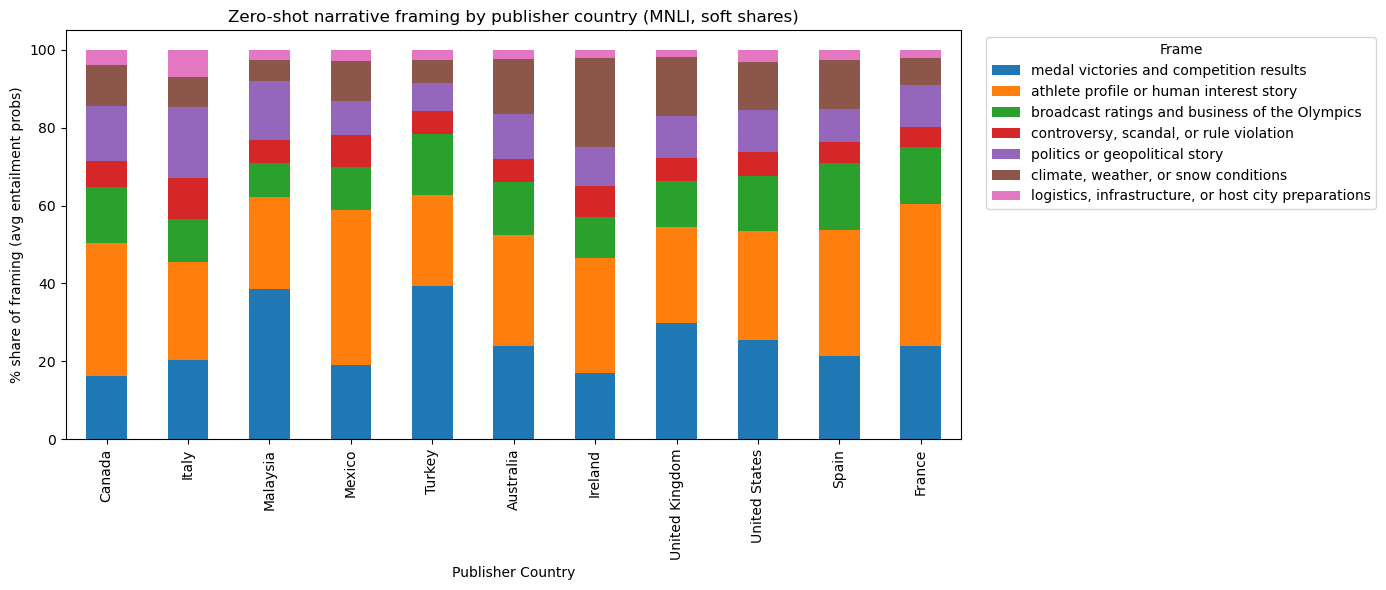

In [69]:
plot_df = country_frame_pct.loc[
    country_frame_pct.sum(axis=1).sort_values(ascending=False).index
]

plot_df.plot(kind="bar", stacked=True, figsize=(14,6))
plt.title("Zero-shot narrative framing by publisher country (MNLI, soft shares)")
plt.ylabel("% share of framing (avg entailment probs)")
plt.xlabel("Publisher Country")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Frame")
plt.tight_layout()
plt.savefig("../figures/publisher_NLP_url_slug_classification_stacked_barchart.png")
plt.show()

In [71]:
frame_tone = (
    zs_df
    .groupby("top_label")["top_prob"]
    .mean()
    .sort_values(ascending=False)
)

frame_tone

top_label
medal victories and competition results                 0.579709
athlete profile or human interest story                 0.474854
broadcast ratings and business of the Olympics          0.431049
controversy, scandal, or rule violation                 0.423449
climate, weather, or snow conditions                    0.403038
politics or geopolitical story                          0.401309
logistics, infrastructure, or host city preparations    0.297012
Name: top_prob, dtype: float32

## Narrative Framing vs Tone

Find out what drives the tone of a news coverage.
- Are narrative framing and tone correlated?
- Does focus on reporting about medals and athletes drive positive tone?


In [73]:
# Average tone per country
tone_country = (
    df[df["rel_strict"]]
        .groupby("publisher_country_final")["tone"]
        .mean()
)

# Merge with framing shares
analysis_df = country_frame_pct.copy()
analysis_df["avg_tone"] = tone_country

analysis_df

,medal victories and competition results,athlete profile or human interest story,broadcast ratings and business of the Olympics,"controversy, scandal, or rule violation",politics or geopolitical story,"climate, weather, or snow conditions","logistics, infrastructure, or host city preparations",avg_tone
publisher_country_final,,,,,,,,
Australia,23.790169,28.756718,13.534397,5.860343,11.497296,14.104493,2.456585,1.113748
Canada,16.275328,34.097832,14.417187,6.765029,14.035662,10.453421,3.955549,1.656215
France,23.828014,36.512085,14.643888,5.248353,10.661467,7.092364,2.013819,0.923788
Ireland,17.041449,29.352173,10.727299,7.983087,9.806071,22.878418,2.211500,1.195144
Italy,20.222136,25.189781,11.057170,10.566704,18.197374,7.844363,6.922479,1.980412
Malaysia,38.433533,23.755100,8.852160,5.870785,14.947310,5.487110,2.653996,2.364486
Mexico,19.054029,39.782394,11.107499,8.178152,8.751621,10.125526,3.000775,1.156091
Spain,21.396036,32.241192,17.188889,5.560622,8.421998,12.679243,2.512007,0.872961
Turkey,39.269020,23.394173,15.747841,5.897015,7.212391,5.937908,2.541653,3.456683


In [75]:
# Correlation
corr = analysis_df.corr()

corr["avg_tone"].sort_values(ascending=False)

avg_tone                                                1.000000
medal victories and competition results                 0.772840
logistics, infrastructure, or host city preparations    0.120042
politics or geopolitical story                          0.065277
controversy, scandal, or rule violation                -0.010919
broadcast ratings and business of the Olympics         -0.103371
climate, weather, or snow conditions                   -0.430362
athlete profile or human interest story                -0.736762
Name: avg_tone, dtype: float64

In [77]:
import sys
!{sys.executable} -m pip install statsmodels

In [79]:
# Regression: medal victories coverage on tone

import statsmodels.api as sm

X = analysis_df[["medal victories and competition results"]]
X = sm.add_constant(X)
y = analysis_df["avg_tone"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               avg_tone   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     13.35
Date:                Tue, 21 Apr 2026   Prob (F-statistic):            0.00529
Time:                        13:55:10   Log-Likelihood:                -7.3367
No. Observations:                  11   AIC:                             18.67
Df Residuals:                       9   BIC:                             19.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -0.2087      0.545     -0.383      0.711      -1.443       1.025
medal victories and competition results     0.0764      0.021      3.654      0.005       0.029       0.124
==============================================================================
Omnibus:                        1.758   Durbin-Watson:                   2.841
Prob(Omnibus):                  0.415   Jarque-Bera (JB):                0.825
Skew:                           0.118   Prob(JB):                        0.662
Kurtosis:                       1.679   Cond. No.                         90.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Regression Insights

- Medal-focused framing explains approximately 60% of cross-country variation in tone during the Milano Cortina 2026 Winter Olympics.
- (+0.0764) in tone for every 1% more coverage of medals and victories!

/var/folders/gc/cn0r60wn7j5bsfkl23_ym9_80000gn/T/ipykernel_3868/3480986033.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"$R^2$ = {model.rsquared:.2f}\np = {model.pvalues[1]:.3f}",


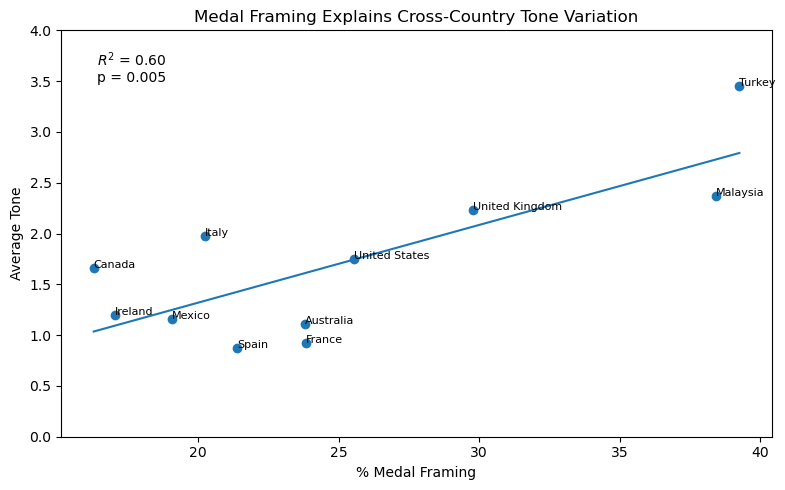

In [81]:
x = analysis_df["medal victories and competition results"]
y = analysis_df["avg_tone"]

# Fit line
coef = model.params
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = coef["const"] + coef["medal victories and competition results"] * x_vals

plt.figure(figsize=(8,5))

plt.scatter(x, y)

for country in analysis_df.index:
    plt.text(x.loc[country], y.loc[country], country, fontsize=8)

plt.plot(x_vals, y_vals)

plt.xlabel("% Medal Framing")
plt.ylabel("Average Tone")
plt.title("Medal Framing Explains Cross-Country Tone Variation")
plt.ylim(0,4)
plt.text(
    0.05,
    0.95,
    f"$R^2$ = {model.rsquared:.2f}\np = {model.pvalues[1]:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.tight_layout()
plt.savefig("../figures/regression_medal_framing_on_tone.png")
plt.show()

In [83]:
# 2 variable model

X = analysis_df[[
    "medal victories and competition results",
    "controversy, scandal, or rule violation",
]]

X = sm.add_constant(X)
y = analysis_df["avg_tone"]

model_2 = sm.OLS(y, X).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               avg_tone   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     11.90
Date:                Tue, 21 Apr 2026   Prob (F-statistic):            0.00401
Time:                        13:55:16   Log-Likelihood:                -4.7489
No. Observations:                  11   AIC:                             15.50
Df Residuals:                       8   BIC:                             16.69
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.1708      1.005     -2.160      0.063      -4.488       0.147
medal victories and competition results     0.0964      0.020      4.878      0.001       0.051       0.142
controversy, scandal, or rule violation     0.2168      0.099      2.192      0.060      -0.011       0.445
==============================================================================
Omnibus:                        2.660   Durbin-Watson:                   2.262
Prob(Omnibus):                  0.265   Jarque-Bera (JB):                1.498
Skew:                           0.887   Prob(JB):                        0.473
Kurtosis:                       2.655   Cond. No.                         206.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretation

- 

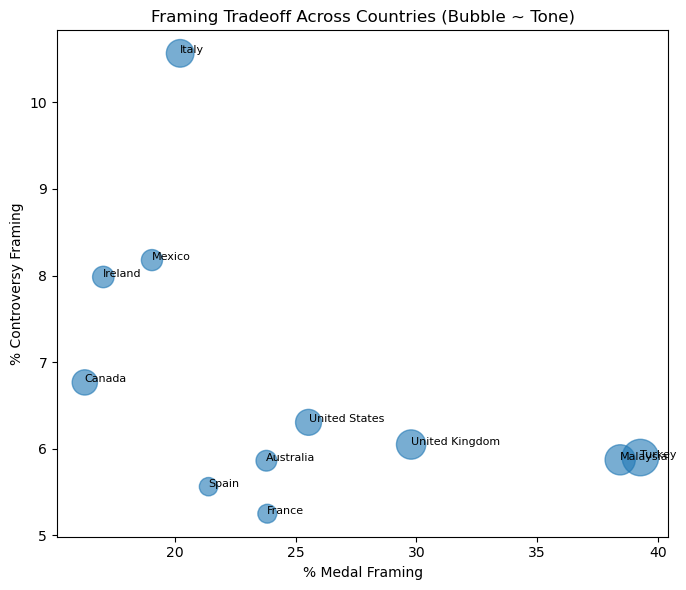

In [85]:
plt.figure(figsize=(7,6))
plt.scatter(
    analysis_df["medal victories and competition results"],
    analysis_df["controversy, scandal, or rule violation"],
    s=analysis_df["avg_tone"] * 200,
    alpha=0.6
)

for country in analysis_df.index:
    plt.text(
        analysis_df.loc[country, "medal victories and competition results"],
        analysis_df.loc[country, "controversy, scandal, or rule violation"],
        country,
        fontsize=8
    )

plt.xlabel("% Medal Framing")
plt.ylabel("% Controversy Framing")
plt.title("Framing Tradeoff Across Countries (Bubble ~ Tone)")
plt.tight_layout()
plt.show()